Model - Val Accuracy - Epochs

Dense - 84.11 - 2

Dense_Improve - 87.06 - 3

CNN - 89.35 - 3

CNN_Improve - 89.79 - 2

RNN - 81.00 - 4

RNN_Improve - 84.37 - 4

LSTM - 84.47 - 2

LSTM_Improve - 85.04 - 3

BiLSTM - 87.01 - 3

BiLSTM - 87.80 - 3

Non-Sequential - 89.50 - 2

Non-Sequential_Improve - 89.75 - 2

In [ ]:
import keras
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Model
from keras.layers import Input, concatenate
from keras.layers import Dense, Dropout, Embedding, SpatialDropout1D, Conv1D, GlobalMaxPooling1D
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
import os
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# output directory name:
output_dir = 'model_output/multiconv'

# training:
epochs = 6
batch_size = 64

# vector-space embedding:
n_dim = 128
n_unique_words = 5000
max_review_length = 400
pad_type = trunc_type = 'pre'
drop_embed = 0.2

# convolutional layer architecture:
n_conv_1 = n_conv_2 = n_conv_3 = 256
k_conv_1 = 3
k_conv_2 = 2
k_conv_3 = 4

# dense layer architecture:
n_dense = 256
dropout = 0.5
learning_rate = 0.0005

In [ ]:
(x_train, y_train), (x_valid, y_valid) = imdb.load_data(num_words=n_unique_words)

x_train = pad_sequences(x_train, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)
x_valid = pad_sequences(x_valid, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# With the Model class, we specify the Input() layer independently, as opposed to specifying it as
# the shape argument of the first hidden layer. We specified the data type (dtype) explicitly:
# 16-bit integers (int16) can range up to 32,767, which will accommodate the maximum index of
# the words we input.59 As with all of the layers in this model, we specify a recognizable name
# argument so that when we print the model later (using model.summary()) it will be easy to make sense of everything.
input_layer = Input(shape=(max_review_length,), dtype='int16', name='input')
# Every layer is assigned to a unique variable name, such as input_layer, embedding_layer, and conv_2.
# We will use these variable names to specify the flow of data within our model.

# embedding: The most noteworthy aspect of using the Model class, which will be familiar to developers
# who have worked with functional programming languages, is the variable name within the second set of
# parentheses following any layer call. This specifies which layer’s outputs are flowing into a given layer.
# For example, (input_layer) in the second set of parentheses of the embedding_layer indicates that the
# output of the input layer flows into the embedding layer.
embedding_layer = Embedding(n_unique_words, n_dim, name='embedding')(input_layer)
drop_embed_layer = SpatialDropout1D(drop_embed, name='drop_embed')(embedding_layer)

# three parallel convolutional streams: The output of the SpatialDropout1D layer (with a variable named
# drop_embed_layer) is the input to three separate, parallel convolutional layers: conv_1, conv_2, and conv_3.
# three convolutional streams includes a Conv1D layer (with a unique k_conv filter length) and a GlobalMaxPooling1D layer
conv_1 = Conv1D(n_conv_1, k_conv_1, activation='relu', name='conv_1')(drop_embed_layer)
maxp_1 = GlobalMaxPooling1D(name='maxp_1')(conv_1)

conv_2 = Conv1D(n_conv_2, k_conv_2, activation='relu', name='conv_2')(drop_embed_layer)
maxp_2 = GlobalMaxPooling1D(name='maxp_2')(conv_2)

conv_3 = Conv1D(n_conv_3, k_conv_3, activation='relu', name='conv_3')(drop_embed_layer)
maxp_3 = GlobalMaxPooling1D(name='maxp_3')(conv_3)

# The activations output by the GlobalMaxPooling1D layer of each of the three convolutional streams are concatenated
# into a single array of activation values by the concatenate() layer, which takes in a list of
# inputs ([maxp_1, maxp_2, maxp_3]) as its only argument.
concat = concatenate([maxp_1, maxp_2, maxp_3])

# dense hidden layers: The concatenated convolutional-stream activations are provided as input to two Dense() hidden
# layers, each of which has a Dropout() layer associated with it. (The second dense layer has one-quarter as many
# neurons as the first, as specified by n_dense/4.)
dense_layer = Dense(n_dense, activation='relu', name='dense')(concat)
drop_dense_layer = Dropout(dropout, name='drop_dense')(dense_layer)
dense_2 = Dense(int(n_dense/4), activation='relu', name='dense_2')(drop_dense_layer)
dropout_2 = Dropout(dropout, name='drop_dense_2')(dense_2)

# sigmoid output layer: The activations output by the sigmoid output neuron (ŷ) are assigned to the variable name predictions.
predictions = Dense(1, activation='sigmoid', name='output')(dropout_2)

# create model: Finally, the Model class ties all of the model's layers together by taking two arguments: the variable
# name of the input layer (i.e., input_layer) and the output layer (i.e., predictions).
model = Model(input_layer, predictions)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 400)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 128)  │    640,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_embed          │ (None, 400, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv1D)     │ (None, 398, 256)  │     98,560 │ drop_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv1D)     │ (None, 399, 256)  │     65,792 │ drop_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 397, 256)  │    131,328 │ drop_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxp_1              │ (None, 256)       │          0 │ conv_1[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxp_2              │ (None, 256)       │          0 │ conv_2[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxp_3              │ (None, 256)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ maxp_1[0][0],     │
│ (Concatenate)       │                   │            │ maxp_2[0][0],     │
│                     │                   │            │ maxp_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    196,864 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense          │ (None, 256)       │          0 │ dense[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     16,448 │ drop_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense_2        │ (None, 64)        │          0 │ dense_2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ drop_dense_2[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,149,057 (4.38 MB)

 Trainable params: 1,149,057 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(learning_rate=learning_rate)

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

modelcheckpoint = ModelCheckpoint(filepath=output_dir+"/model_epoch_{epoch:02d}.keras")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_valid, y_valid), callbacks=[modelcheckpoint])

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.7196 - loss: 0.5159 - val_accuracy: 0.8658 - val_loss: 0.3047
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8969 - loss: 0.2702 - val_accuracy: 0.8975 - val_loss: 0.2521
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9331 - loss: 0.1860 - val_accuracy: 0.8966 - val_loss: 0.2599
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9616 - loss: 0.1159 - val_accuracy: 0.8855 - val_loss: 0.3254
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.9739 - loss: 0.0758 - val_accuracy: 0.8840 - val_loss: 0.3550
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9818 - loss: 0.0541 - val_accuracy: 0.8920 - val_loss: 0.4267


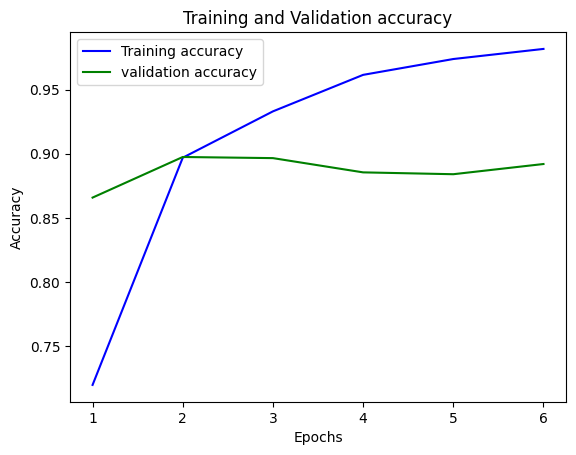

In [ ]:
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1, 7) # range end will be epoch + 1
plt.plot(epochs, loss_train, 'b', label='Training accuracy')
plt.plot(epochs, loss_val, 'g', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

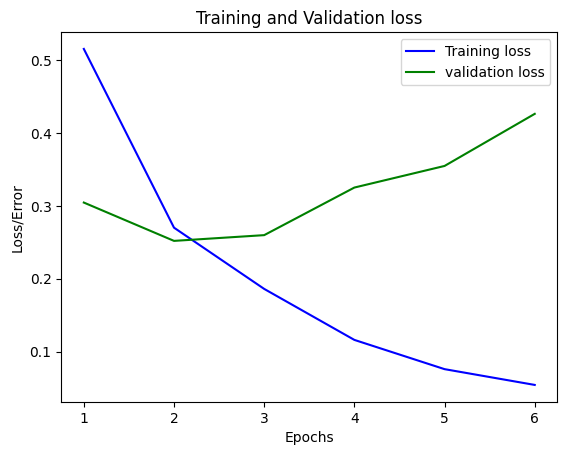

In [ ]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1, 7) # range end will be epoch + 1
plt.plot(epochs, loss_train, 'b', label='Training loss')
plt.plot(epochs, loss_val, 'g', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss/Error')
plt.legend()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


'96.12'

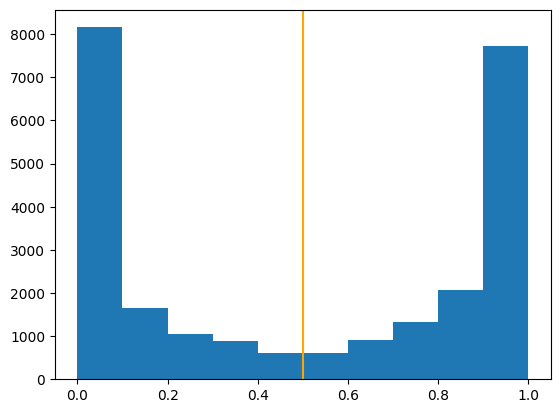

In [ ]:
model.load_weights(output_dir+"/model_epoch_02.keras")

y_hat = model.predict(x_valid)

plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')

"{:0.2f}".format(roc_auc_score(y_valid, y_hat)*100.0)

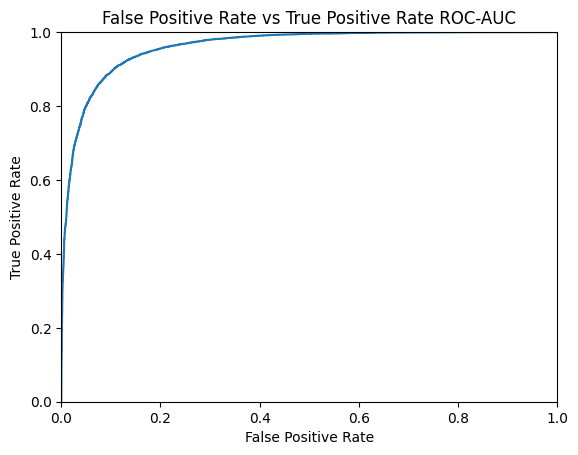

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_valid, y_hat)
plt.plot(fpr, tpr)
plt.axis([0, 1, 0, 1])
plt.title('False Positive Rate vs True Positive Rate ROC-AUC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()